# Exploratory Data Analysis

This section analyzes the cleaned social-media posts dataset and the associated user dataset.

The analysis focuses on:
- dataset structure and completeness
- posting activity over time
- platform distribution
- engagement patterns
- user-level activity
- follower count and engagement
- language and location
- text characteristics
- relationships between variables
- notable observations and anomalies

Each visualization is used to answer a specific analytical question.

In [8]:
!pip install matplotlib
!pip install seaborn
!pip install pandas

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

df_posts = pd.read_csv('Social_Engine_Posts_Cleaned.csv')
df_users = pd.read_csv('Social_Engine_Users.csv')

print("Posts:", df_posts.shape)
print("Users:", df_users.shape)

Posts: (12000, 9)
Users: (1500, 5)


## 1. Dataset Overview

The first step is to establish the size, structure, date range, and completeness of the cleaned datasets.

In [11]:
print("Posts dataset:")
display(df_posts.head())

print("\nUsers dataset:")
display(df_users.head())

print("\nPost date range:")
print(df_posts['date'].min(), "to", df_posts['date'].max())

print("\nNumber of unique users with posts:")
print(df_posts['user_id'].nunique())

print("\nMissing values in posts:")
post_missing = df_posts.drop(columns=['time']).isna().sum()
display(post_missing.sort_values(ascending=False))

print("\nMissing values in users:")
display(df_users.isna().sum().sort_values(ascending=False))

Posts dataset:


,post_id,user_id,platform,text_content,likes,shares,comments,date,time
0,to64mgey2v3y,user_vfxs1pry,Reddit,Bummed out with my new Air Max from Nike! Abso...,4488.0,1456,673,2024-09-25,NaN
1,7f0wdauzbj89,user_8l7rv5oe,Reddit,My one month review of Pepsi Crystal Pepsi: Hi...,789.0,1484,39,2024-08-01,16:14:00
2,dvvhg8eel45x,user_nfo3ih5u,NaN,Just unboxed my new Highlander from Toyota. Ex...,NaN,1410,839,2025-04-13,20:12:18
3,hgb9cxke4t7b,user_27aje6ur,Facebook,Comparing Pepsi Crystal Pepsi to the competiti...,167.0,584,833,2024-09-10,NaN
4,zwerpw3wk320,user_9px5q0by,Reddit,My one week review of Coca-Cola Diet Coke: Bes...,4749.0,152,630,2024-05-31,NaN



Users dataset:


,user_id,location,language,account_created,follower_count
0,user_guglt5jp,"Berlin, Germany",ja,2023-10-23,38963
1,user_b1p3wz81,"Munich, Germany",zh,2023-05-06,24644
2,user_jm2grmis,"Dubai, UAE",en,2023-01-03,45842
3,user_ykoqww5l,"Paris, France",fr,2023-10-11,665
4,user_3zzvv8vp,"Los Angeles, USA",ru,2023-05-23,42908



Post date range:
2024-05-01 to 2025-04-30

Number of unique users with posts:
1500

Missing values in posts:


likes           1814
platform        1784
text_content    1760
user_id            0
post_id            0
shares             0
comments           0
date               0
dtype: int64


Missing values in users:


user_id            0
location           0
language           0
account_created    0
follower_count     0
dtype: int64

In [ ]:
print("Descriptive statistics for engagement:")
display(df_posts[['likes', 'shares', 'comments']].describe())

print("\nPlatform distribution:")
display(df_posts['platform'].value_counts(dropna=False))

print("\nUser language distribution:")
display(df_users['language'].value_counts(dropna=False).head(15))

print("\nUser location distribution:")
display(df_users['location'].value_counts(dropna=False).head(15))

## 2. Platform Distribution

**Question:** How are posts distributed across the available platforms?

A count plot is used because platform is categorical and the objective is to compare post volume.

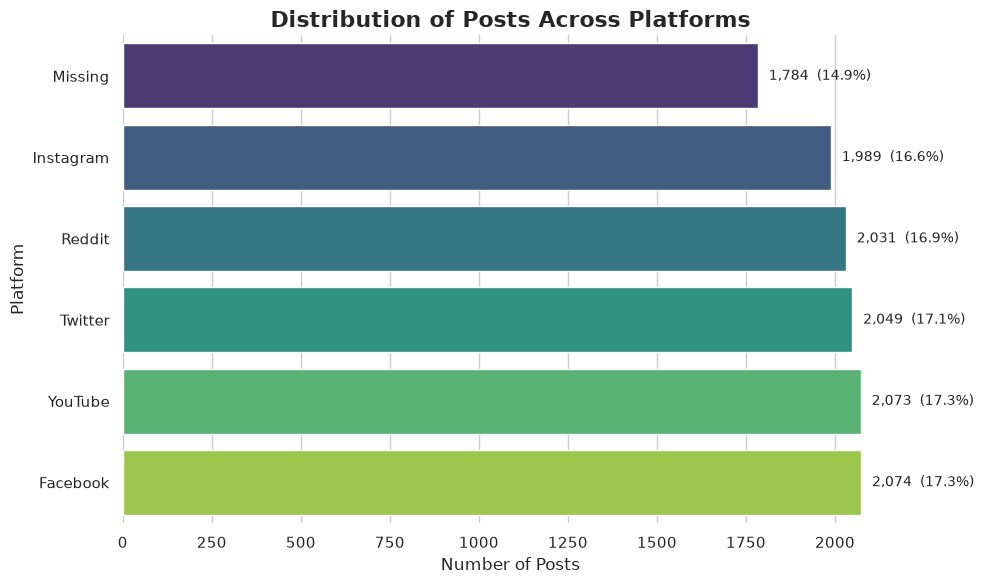

In [13]:
plt.figure(figsize=(10, 6))

platform_counts = (
    df_posts['platform']
    .fillna('Missing')
    .value_counts()
    .sort_values()
)

ax = sns.barplot(
    x=platform_counts.values,
    y=platform_counts.index,
    hue=platform_counts.index,
    palette='viridis',
    legend=False
)

total_posts = len(df_posts)

for i, count in enumerate(platform_counts.values):
    percentage = (count / total_posts) * 100
    ax.text(
        count + 30,
        i,
        f'{count:,}  ({percentage:.1f}%)',
        va='center',
        fontsize=10
    )

plt.title('Distribution of Posts Across Platforms', fontsize=16, fontweight='bold')
plt.xlabel('Number of Posts')
plt.ylabel('Platform')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## 3. Posting Activity Over Time

**Question:** How does posting activity change across the dataset's time period?

The daily post count is plotted as a time series. This helps identify periods of unusually high or low activity.

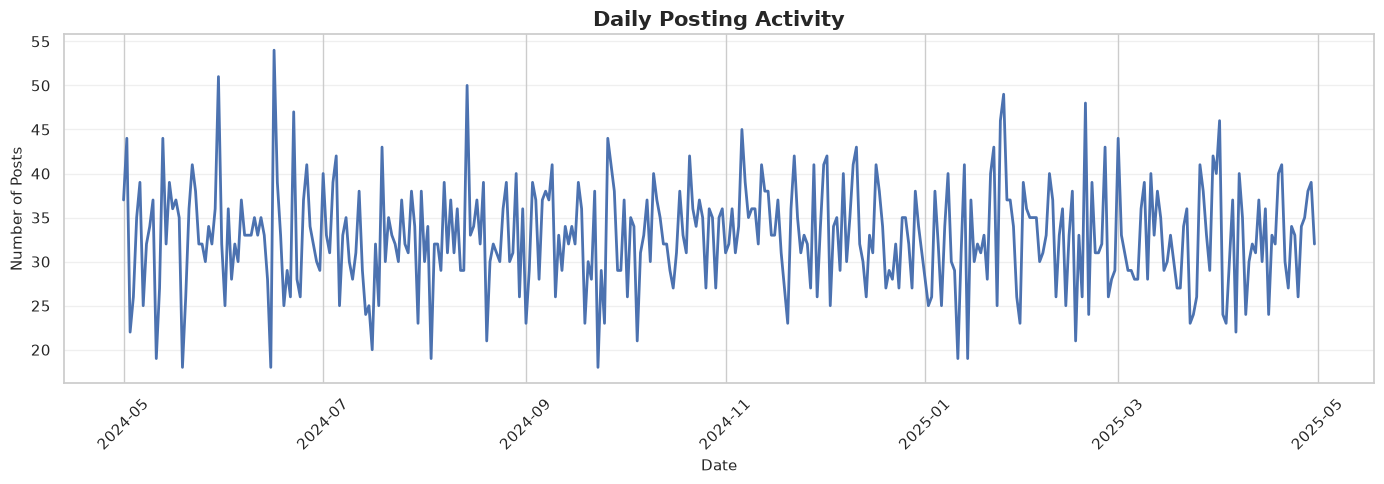

In [14]:
daily_posts = (
    df_posts.groupby('date')
    .size()
    .reset_index(name='post_count')
)

daily_posts['date'] = pd.to_datetime(daily_posts['date'])

plt.figure(figsize=(14, 5))

sns.lineplot(
    data=daily_posts,
    x='date',
    y='post_count',
    linewidth=2
)

plt.title('Daily Posting Activity', fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('Number of Posts', fontsize=11)

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Posting Activity by Day of Week

**Question:** Which days of the week have the highest posting activity?

In [ ]:
date_values = pd.to_datetime(df_posts['date'], errors='coerce')

weekday_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

weekday_counts = date_values.dt.day_name().value_counts().reindex(weekday_order)

plt.figure(figsize=(9, 5))
sns.barplot(x=weekday_counts.index, y=weekday_counts.values)
plt.title('Posts by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Posts')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 5. Posting Activity by Hour

**Question:** At which hours are posts most frequently published?

Only records with a known time are included. Date-only records are excluded because their original posting time is unknown.

In [ ]:
time_values = pd.to_datetime(
    df_posts['time'],
    format='%H:%M:%S',
    errors='coerce'
)

hour_counts = time_values.dt.hour.value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.barplot(x=hour_counts.index, y=hour_counts.values)
plt.title('Posts by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Posts')
plt.tight_layout()
plt.show()

## 6. Engagement Distributions

**Question:** How are likes, shares, and comments distributed?

Engagement variables are commonly right-skewed, so both the distribution and summary statistics should be considered. Histograms are used to inspect the overall shape.

In [ ]:
engagement_columns = ['likes', 'shares', 'comments']

for column in engagement_columns:
    plt.figure(figsize=(9, 5))
    sns.histplot(data=df_posts, x=column, bins=50)
    plt.title(f'Distribution of {column.title()}')
    plt.xlabel(column.title())
    plt.ylabel('Number of Posts')
    plt.tight_layout()
    plt.show()

## 7. Engagement by Platform

**Question:** Does engagement differ between platforms?

Box plots show the median, spread, and potential extreme values for each platform. Extreme values are retained because they may represent genuine high-engagement posts.

In [ ]:
for column in engagement_columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df_posts, x='platform', y=column)
    plt.title(f'{column.title()} by Platform')
    plt.xlabel('Platform')
    plt.ylabel(column.title())
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

## 8. Likes and Shares Relationship

**Question:** Do posts with more likes also tend to receive more shares?

The scatter plot compares the two engagement measures and uses platform as a grouping variable.

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_posts,
    x='likes',
    y='shares',
    hue='platform',
    alpha=0.6
)
plt.title('Likes vs Shares')
plt.xlabel('Likes')
plt.ylabel('Shares')
plt.tight_layout()
plt.show()

## 9. Likes and Comments Relationship

**Question:** Is higher like activity associated with higher comment activity?

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_posts,
    x='likes',
    y='comments',
    hue='platform',
    alpha=0.6
)
plt.title('Likes vs Comments')
plt.xlabel('Likes')
plt.ylabel('Comments')
plt.tight_layout()
plt.show()

## 10. Engagement Correlation

**Question:** How strongly are likes, shares, and comments related to one another?

A correlation matrix summarizes linear relationships between the engagement variables.

In [ ]:
engagement_corr = df_posts[engagement_columns].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(engagement_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Engagement Correlation Matrix')
plt.tight_layout()
plt.show()

## 11. User-Level Analysis

The posts dataset is joined with the user dataset using `user_id`.

This allows post activity and engagement to be examined in relation to user attributes such as follower count, language, and location.

In [ ]:
user_post_data = df_posts.merge(
    df_users,
    on='user_id',
    how='left',
    validate='many_to_one'
)

print("Merged dataset shape:", user_post_data.shape)
print("Users without matching profile data:", user_post_data['location'].isna().sum())

### Most Active Users

**Question:** Which users publish the largest number of posts?

In [ ]:
top_active_users = (
    user_post_data.groupby('user_id')
    .agg(
        post_count=('post_id', 'count'),
        follower_count=('follower_count', 'first'),
        location=('location', 'first'),
        language=('language', 'first')
    )
    .sort_values('post_count', ascending=False)
    .head(10)
)

display(top_active_users)

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_active_users.reset_index(),
    x='post_count',
    y='user_id'
)
plt.title('Top 10 Users by Number of Posts')
plt.xlabel('Number of Posts')
plt.ylabel('User ID')
plt.tight_layout()
plt.show()

### Follower Count vs Likes

**Question:** Does follower count appear to be associated with the number of likes received?

The scatter plot compares user follower count with post likes.

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=user_post_data,
    x='follower_count',
    y='likes',
    hue='platform',
    alpha=0.6
)
plt.title('Follower Count vs Likes')
plt.xlabel('Follower Count')
plt.ylabel('Likes')
plt.tight_layout()
plt.show()

## 12. Language Analysis

**Question:** Which languages are most represented among users, and how many posts are associated with them?

In [ ]:
language_posts = (
    user_post_data['language']
    .value_counts(dropna=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=language_posts.values, y=language_posts.index)
plt.title('Top User Languages by Number of Posts')
plt.xlabel('Number of Posts')
plt.ylabel('Language')
plt.tight_layout()
plt.show()

## 13. Location Analysis

**Question:** Which locations contribute the most posts?

Only the most frequent locations are displayed to keep the comparison readable.

In [ ]:
location_posts = (
    user_post_data['location']
    .value_counts(dropna=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=location_posts.values, y=location_posts.index)
plt.title('Top User Locations by Number of Posts')
plt.xlabel('Number of Posts')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

## 14. Text Characteristics

**Question:** Does text length vary across posts, and is text length associated with engagement?

Text length is measured in characters after the cleaning process. Missing text remains missing.

In [ ]:
df_posts['text_length'] = df_posts['text_content'].str.len()

print("Text length summary:")
display(df_posts['text_length'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(data=df_posts, x='text_length', bins=50)
plt.title('Distribution of Post Text Length')
plt.xlabel('Text Length (characters)')
plt.ylabel('Number of Posts')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_posts,
    x='text_length',
    y='likes',
    hue='platform',
    alpha=0.6
)
plt.title('Text Length vs Likes')
plt.xlabel('Text Length (characters)')
plt.ylabel('Likes')
plt.tight_layout()
plt.show()

## 15. Overall Variable Correlation

This matrix combines numeric post-level engagement measures with user follower count.

Correlation indicates linear association, not causation.

In [ ]:
numeric_columns = [
    'likes',
    'shares',
    'comments',
    'follower_count',
    'text_length'
]

overall_corr = user_post_data[numeric_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(overall_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numeric Variables')
plt.tight_layout()
plt.show()

## 16. High-Engagement Posts

**Question:** Which posts have unusually high total engagement?

A simple engagement score is calculated as the sum of likes, shares, and comments. This is used only to rank posts by total recorded interactions; it does not imply that each interaction has equal real-world value.

In [ ]:
df_posts['total_engagement'] = (
    df_posts['likes'].fillna(0)
    + df_posts['shares'].fillna(0)
    + df_posts['comments'].fillna(0)
)

top_engagement_posts = (
    df_posts[
        ['post_id', 'user_id', 'platform', 'date',
         'likes', 'shares', 'comments', 'total_engagement']
    ]
    .sort_values('total_engagement', ascending=False)
    .head(10)
)

display(top_engagement_posts)

## 17. EDA Summary

The final report should record observations supported by the generated tables and visualizations.

Recommended observations to document after running the notebook:
- the overall number of cleaned posts and users
- the balance of posts across platforms
- the busiest and least active periods
- the most active days and hours
- the typical and extreme engagement levels
- differences in engagement across platforms
- relationships between likes, shares, and comments
- the most active users
- the relationship between follower count and engagement
- dominant languages and locations
- the distribution of text length
- notable high-engagement posts

Observations should be based on the actual notebook output rather than assumptions made before execution.